# ECON 5140: Applied Econometrics
## Homework 3: Causal Inference — Potential Outcomes & Matching

**Covers:** Lesson 7 (Potential Outcomes & DAGs) & Lesson 9 (Matching for Causal Inference)

---

# PART 2: CODING PROBLEMS

## Problem 5: Propensity Score Model (Coding)

**Context (tech company):** A SaaS company rolled out an AI assistant feature in a phased rollout. Power users and higher-tier customers were more likely to get early access. You want to estimate the causal effect of the feature on **weekly active minutes**.

**Variables:**
- **D** = 1 if user had access to AI assistant, 0 otherwise
- **Y** = weekly_active_minutes (outcome)
- **plan_tier**: 0=free, 1=pro, 2=enterprise
- **tenure_days**: days since signup (0–365)
- **prior_sessions**: sessions in past 30 days before launch
- **platform**: 0=web, 1=mobile
- **signup_cohort**: 0=Q1, 1=Q2, 2=Q3 (quarter of signup)

**True causal effect:** +15 minutes per week. Treatment is *not* random—selection on observables.

**Your tasks:**

1. **Use the simulated data** below (or generate your own with the same DGP).

2. **Estimate the propensity score** e(X) = Pr(D=1|X) using logistic regression of D on all covariates. Print the model summary. Which covariates most increase the probability of treatment?

3. **Add fitted propensity scores** to the dataset.

4. **Check overlap:** Plot propensity score distributions for treated vs control (KDE or histogram). Is overlap sufficient?

5. **Compute ATE via IPW.** Compare naive ATE, IPW ATE, and true effect (15). Briefly interpret.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

# Simulated data: AI assistant feature rollout (phased, not random)
n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

# Treatment: higher tier, tenure, prior sessions, mobile → more likely to get feature
logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: weekly_active_minutes. True effect of feature = +15 min
Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print("Dataset: AI assistant feature rollout")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True causal effect: +15 min/week")
print(df.head(10))

Dataset: AI assistant feature rollout
  n = 600, Treated: 254, Control: 346
  True causal effect: +15 min/week
   plan_tier  tenure_days  prior_sessions  platform  signup_cohort  D  \
0          1          231              16         1              2  0   
1          0          276              28         0              2  0   
2          0          345              21         0              1  1   
3          1          353              23         0              1  1   
4          1           39              15         0              0  0   
5          0          205              28         0              0  0   
6          2          298              17         0              0  0   
7          1           58              31         0              0  1   
8          0           48              14         1              2  0   
9          0          174               9         0              2  0   

   weekly_active_minutes  
0             132.725826  
1             114.294894  
2   


Propensity score model: D ~ covariates (logistic regression)
Intercept: -1.2793

Coefficients (positive -> higher Pr(D=1)):
                  coef  abs_coef
plan_tier       0.5216    0.5216
platform        0.4223    0.4223
signup_cohort   0.2009    0.2009
tenure_days     0.0022    0.0022
prior_sessions -0.0049    0.0049

Top covariates increasing Pr(D=1): ['plan_tier', 'platform', 'signup_cohort']


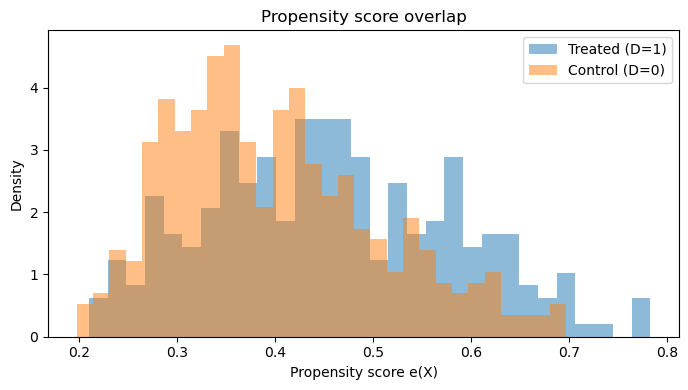


Propensity score quantiles:
Treated: {0.01: 0.2287, 0.05: 0.2674, 0.5: 0.4473, 0.95: 0.6633, 0.99: 0.7463}
Control: {0.01: 0.218, 0.05: 0.2578, 0.5: 0.3847, 0.95: 0.6054, 0.99: 0.6707}

ATE estimates (minutes per week):
Naive ATE (no adjustment): 18.798
IPW ATE (propensity score): 15.390
True causal effect used in DGP: 15.000


In [2]:
# Problem 5: Propensity Score Model + IPW
# Covariates: plan_tier, tenure_days, prior_sessions, platform, signup_cohort
# Outcome: weekly_active_minutes. True effect = 15

covariates = ['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']
X = df[covariates]
y = df['D']

# 1) Fit logistic regression: e(X)=Pr(D=1|X)
ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X, y)

# Print a simple model summary (coefficients on the log-odds scale)
coef_table = pd.DataFrame(
    {'coef': ps_model.coef_[0], 'abs_coef': np.abs(ps_model.coef_[0])},
    index=covariates
).sort_values('coef', ascending=False)

print("\nPropensity score model: D ~ covariates (logistic regression)")
print(f"Intercept: {ps_model.intercept_[0]:.4f}")
print("\nCoefficients (positive -> higher Pr(D=1)):")
print(coef_table[['coef', 'abs_coef']].round(4))

# 2) Add fitted propensity scores

df['ps_raw'] = ps_model.predict_proba(X)[:, 1]
# Clip to avoid extreme weights in the IPW step
df['ps'] = np.clip(df['ps_raw'], 1e-3, 1 - 1e-3)

# Report which covariates most increase treatment probability
top_increasing = coef_table.index[:3].tolist()
print(f"\nTop covariates increasing Pr(D=1): {top_increasing}")

# 3) Check overlap: plot propensity score distributions
ps_treated = df.loc[df['D'] == 1, 'ps']
ps_control = df.loc[df['D'] == 0, 'ps']

plt.figure(figsize=(7, 4))
plt.hist(ps_treated, bins=30, alpha=0.5, density=True, label='Treated (D=1)')
plt.hist(ps_control, bins=30, alpha=0.5, density=True, label='Control (D=0)')
plt.xlabel('Propensity score e(X)')
plt.ylabel('Density')
plt.title('Propensity score overlap')
plt.legend()
plt.tight_layout()
plt.show()

print("\nPropensity score quantiles:")
print("Treated:", ps_treated.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(4).to_dict())
print("Control:", ps_control.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(4).to_dict())

# 4) Compute naive ATE and IPW ATE
Y = df['weekly_active_minutes']
treated_mask = df['D'] == 1
control_mask = ~treated_mask

naive_ate = Y[treated_mask].mean() - Y[control_mask].mean()

# ATE via IPW (weighted difference in means using normalized group weights)
w1 = 1.0 / df.loc[treated_mask, 'ps']              # weights for E[Y(1)]
w0 = 1.0 / (1.0 - df.loc[control_mask, 'ps'])    # weights for E[Y(0)]

EY1 = np.sum(w1 * Y[treated_mask]) / np.sum(w1)
EY0 = np.sum(w0 * Y[control_mask]) / np.sum(w0)
ipw_ate = EY1 - EY0

print("\nATE estimates (minutes per week):")
print(f"Naive ATE (no adjustment): {naive_ate:.3f}")
print(f"IPW ATE (propensity score): {ipw_ate:.3f}")
print("True causal effect used in DGP: 15.000")
